In [1]:
!pip install -q git+https://github.com/huggingface/peft.git transformers bitsandbytes datasets


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 

In [2]:
!pip install fsspec==2025.3.0

In [3]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch

In [4]:

!pip install -q kaggle


In [5]:
# Upload your kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lkjghdflkjv","key":"62c543d170a748face7d52317b0c81c4"}'}

In [6]:
# Move kaggle.json to the correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [7]:
# Download the dataset
!kaggle datasets download -d adityajn105/flickr8k

# Unzip it
!unzip -q flickr8k.zip -d flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0


In [8]:
DATASET_PATH = '/content/flickr8k'
CAPTIONS_FILE = os.path.join(DATASET_PATH, 'captions.txt')
IMAGES_PATH = os.path.join(DATASET_PATH, 'Images/')


In [9]:
# Load and process captions
df = pd.read_csv(CAPTIONS_FILE, sep=',', names=["image", "caption"])


In [10]:
df["caption"] = df["caption"][1:]

In [11]:
df["caption"]

,caption
0,NaN
1,A child in a pink dress is climbing up a set o...
2,A girl going into a wooden building .
3,A little girl climbing into a wooden playhouse .
4,A little girl climbing the stairs to her playh...
...,...
40451,A man in a pink shirt climbs a rock face
40452,A man is rock climbing high in the air .
40453,A person in a red shirt climbing up a rock fac...
40454,A rock climber in a red shirt .


In [12]:
df = df.dropna().reset_index(drop=True)

In [13]:
df

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
...,...,...
40450,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40451,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40452,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40453,997722733_0cb5439472.jpg,A rock climber in a red shirt .


In [14]:
df = df[:8000]

In [15]:
from transformers import AutoProcessor
from PIL import Image

processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")

class Flickr8kDataset(Dataset):
    def __init__(self, dataframe, image_dir, processor):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, row["image"])
        caption = row["caption"]

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Process image
        encoding = self.processor(images=image, return_tensors="pt")
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        encoding["text"] = caption

        return encoding

def collate_fn(batch):
    processed_batch = {}
    for key in batch[0].keys():
        if key != "text":
            processed_batch[key] = torch.stack([example[key] for example in batch])
        else:
            text_inputs = processor.tokenizer(
                [example["text"] for example in batch], padding=True, return_tensors="pt"
            )
            processed_batch["input_ids"] = text_inputs["input_ids"]
            processed_batch["attention_mask"] = text_inputs["attention_mask"]
    return processed_batch


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

In [16]:
from transformers import Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model

model = Blip2ForConditionalGeneration.from_pretrained(
    "ybelkada/blip2-opt-2.7b-fp16-sharded",
    device_map="auto",
    load_in_8bit=True
)

# Apply LoRA
config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj"]
)
model = get_peft_model(model, config)
model.print_trainable_parameters()


config.json:   0%|          | 0.00/7.05k [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


pytorch_model.bin.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

pytorch_model-00003-of-00008.bin:   0%|          | 0.00/985M [00:00<?, ?B/s]

...

pytorch_model-00008-of-00008.bin:   0%|          | 0.00/782M [00:00<?, ?B/s]

pytorch_model-00006-of-00008.bin:   0%|          | 0.00/997M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/127k [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

trainable params: 5,242,880 || all params: 3,749,922,816 || trainable%: 0.1398


In [17]:
# Load dataset
train_dataset = Flickr8kDataset(df, IMAGES_PATH, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=3, collate_fn=collate_fn)

# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.train()

# Training loop
for epoch in range(2):  # Use small epochs for testing, increase later
    print(f"Epoch: {epoch}")
    for idx, batch in enumerate(train_dataloader):
        input_ids = batch.pop("input_ids").to(device)
        pixel_values = batch.pop("pixel_values").to(device, torch.float16)

        outputs = model(input_ids=input_ids, pixel_values=pixel_values, labels=input_ids)
        loss = outputs.loss

        print(f"Batch {idx} Loss: {loss.item():.4f}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


Epoch: 0


Expanding inputs for image tokens in BLIP-2 should be done in processing. Please follow instruction here (https://gist.github.com/zucchini-nlp/e9f20b054fa322f84ac9311d9ab67042) to update your BLIP-2 model. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.


Streaming output truncated to the last 5000 lines.
Batch 335 Loss: 1.3506
Batch 336 Loss: 1.6084
Batch 337 Loss: 1.8271
Batch 338 Loss: 2.1914
Batch 339 Loss: 1.6777
Batch 340 Loss: 1.4932
Batch 341 Loss: 1.9404
Batch 342 Loss: 1.8447
Batch 343 Loss: 2.0039
Batch 344 Loss: 1.8770
Batch 345 Loss: 1.1553
Batch 346 Loss: 1.9600
Batch 347 Loss: 1.8359
Batch 348 Loss: 1.5752
Batch 349 Loss: 1.3857
Batch 350 Loss: 1.9209
Batch 351 Loss: 1.8525
Batch 352 Loss: 0.8921
Batch 353 Loss: 2.2676
Batch 354 Loss: 2.5430
Batch 355 Loss: 1.6680
Batch 356 Loss: 1.9980
Batch 357 Loss: 1.5830
Batch 358 Loss: 1.6797
Batch 359 Loss: 1.7578
Batch 360 Loss: 1.7627
Batch 361 Loss: 1.6973
Batch 362 Loss: 1.7451
Batch 363 Loss: 1.9248
Batch 364 Loss: 1.7266
Batch 365 Loss: 1.7734
Batch 366 Loss: 1.4268
Batch 367 Loss: 1.6113
Batch 368 Loss: 1.8271
Batch 369 Loss: 1.6738
Batch 370 Loss: 2.1387
Batch 371 Loss: 1.4326
Batch 372 Loss: 1.6445
Batch 373 Loss: 1.6357
Batch 374 Loss: 2.5098
Batch 375 Loss: 2.3613
Batch 

In [18]:
# Example prediction
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[0]["image"])).convert('RGB')
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)


Generated caption: A little girl in a pink dress is climbing up a wooden house .


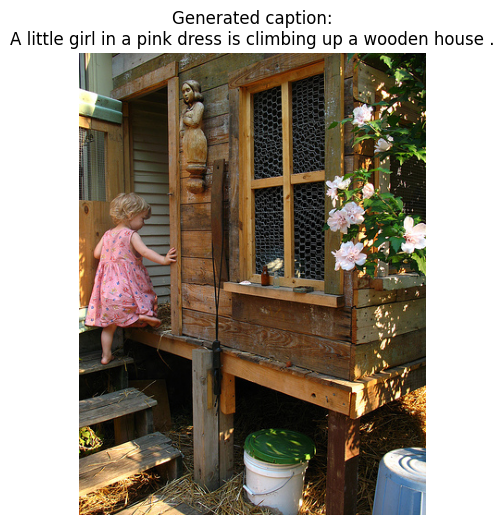

In [19]:
import matplotlib.pyplot as plt

# Show the sample image with the generated caption
plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


Generated caption: Two dogs are one black and white and white dog one brown dog are a white dog are playing with another other


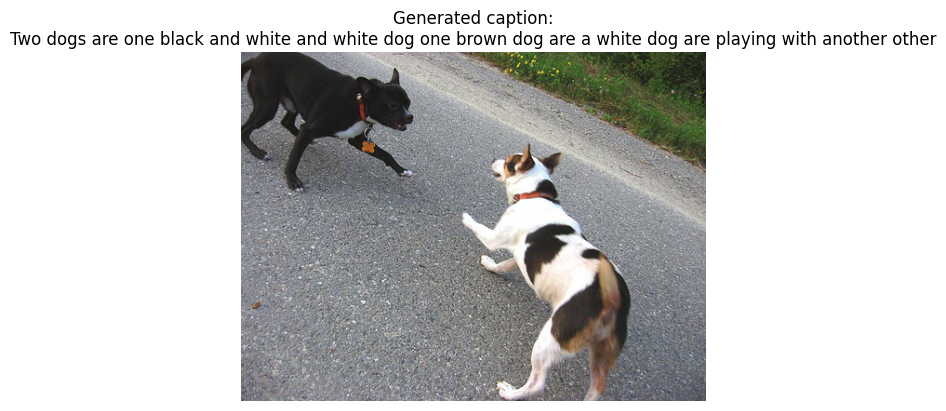

In [20]:
# Load a sample image
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[5]["image"])).convert('RGB')

# Prepare inputs
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)

# Decode caption
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)

# Show image with caption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


Generated caption: A little girl in a pink dress stands outside a wooden house .


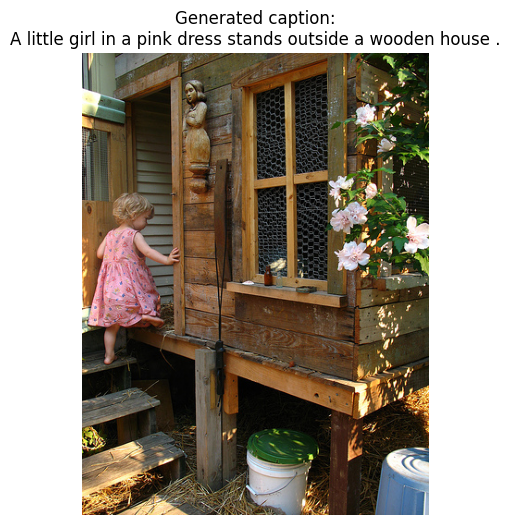

In [21]:
# Load a sample image
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[0]["image"])).convert('RGB')

# Prepare inputs
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)

# Decode caption
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)

# Show image with caption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


Generated caption: A man and a white dog lay on a bench .


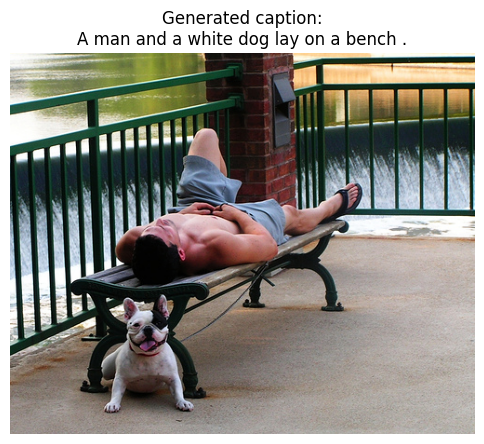

In [22]:
# Load a sample image
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[15]["image"])).convert('RGB')

# Prepare inputs
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)

# Decode caption
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)

# Show image with caption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


Generated caption: A man wearing a hat and glasses wears a hat and glasses looks at a man wearing a beer hat and glasses


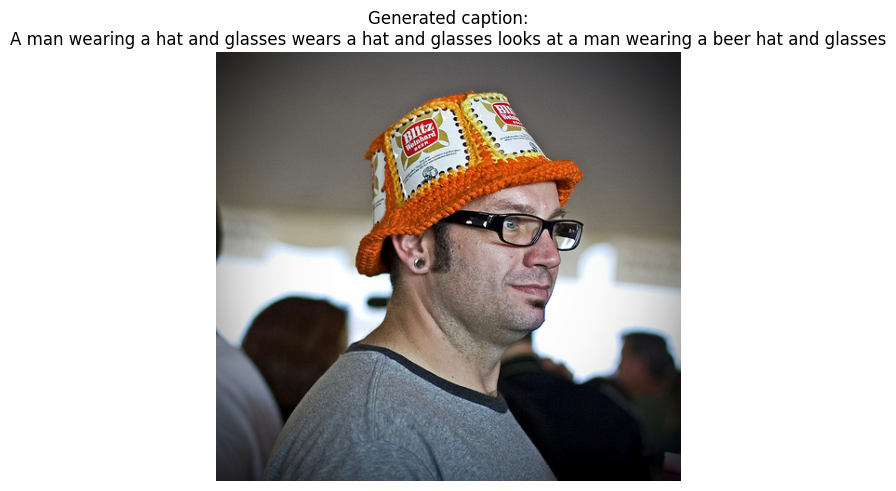

In [23]:
# Load a sample image
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[20]["image"])).convert('RGB')

# Prepare inputs
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)

# Decode caption
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)

# Show image with caption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


Generated caption: A black dog runs over a fallen log .


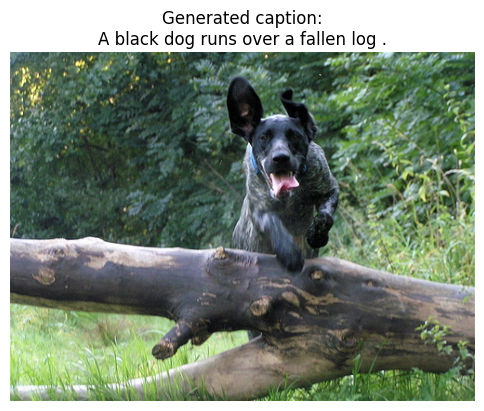

In [24]:
# Load a sample image
sample_image = Image.open(os.path.join(IMAGES_PATH, df.iloc[49]["image"])).convert('RGB')

# Prepare inputs
inputs = processor(images=sample_image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)

# Decode caption
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated caption:", caption)

# Show image with caption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


In [25]:
!pip install evaluate pycocoevalcap --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 7.9 MB/s eta 0:00:00


In [ ]:
import evaluate
from tqdm import tqdm
from PIL import Image
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer

bleu = evaluate.load("bleu")
df = pd.read_csv(CAPTIONS_FILE, sep=',', names=["image", "caption"])

# Get subset
subset_df = df[8001:8092].reset_index(drop=True)

# Collect predictions and references
predictions = []
references = {}

for idx in tqdm(range(len(subset_df))):
    row = subset_df.iloc[idx]
    image_name = row['image']

    image_path = os.path.join(IMAGES_PATH, image_name)
    image = Image.open(image_path).convert('RGB')

    inputs = processor(images=image, return_tensors="pt").to(device, torch.float16)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=25)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    predictions.append(caption)

    if image_name not in references:
        refs = df[df['image'] == image_name]['caption'].tolist()
        references[image_name] = refs

# Prepare for BLEU
gt_list = [references[name] for name in subset_df["image"]]
pred_list = predictions

bleu_score = bleu.compute(predictions=pred_list, references=gt_list)
print("BLEU:", bleu_score)


 64%|██████▎   | 58/91 [03:06<01:43,  3.14s/it]

In [ ]:
# Prepare COCO-style input
gts = {}
res = {}

for i, img in enumerate(subset_df["image"]):
    gts[str(i)] = [{"caption": cap} for cap in references[img]]
    res[str(i)] = [{"caption": predictions[i]}]

# Tokenize
tokenizer = PTBTokenizer()
gts_tokenized = tokenizer.tokenize(gts)
res_tokenized = tokenizer.tokenize(res)

# Compute CIDEr
cider_scorer = Cider()
cider_score, _ = cider_scorer.compute_score(gts_tokenized, res_tokenized)
print("CIDEr:", cider_score)
